In [ ]:
# importando as bibliotecas necessárias para manipulação de dados, modelagem e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importando o dataset biológico (Câncer de mama)
from sklearn.datasets import load_breast_cancer

# importando as ferramentas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# configuração visual para os gráficos
sns.set_theme(style="whitegrid")

In [10]:
# carregando o dataset
data = load_breast_cancer()

# criando um DataFrame do pandas com as features (variáveis independentes)
# na biologia, essas features seriam o raio da célula, textura, área, etc.
df = pd.DataFrame(data.data, columns=data.feature_names)

# adicionando a variável alvo (target) ao DataFrame
# 0 = Maligno (Malignant), 1 = Benigno (Benign)
df['target'] = data.target

# Visualizando as primeiras 5 linhas do dataset para entender sua estrutura
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
# separando as variáveis independentes (X) e a variável alvo (y)
X = df.drop('target', axis=1) # todas as colunas de características da célula
y = df['target']              # apenas o diagnóstico (Maligno/Benigno)

# dividindo o dataset: 80% para treinar o modelo e 20% para testar sua eficácia
# o random_state garante que a divisão seja sempre a mesma (reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de treino: 455 amostras
Tamanho do conjunto de teste: 114 amostras


In [12]:
# inicializando o modelo Random Forest
# n_estimators=100 significa que o modelo criará 100 "árvores de decisão" diferentes
# e a previsão final será a "votação" da maioria dessas árvores.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# treinando (ajustando) o modelo com os dados de treino
rf_model.fit(X_train, y_train)

print("Modelo Random Forest funcionando com sucesso")

Modelo Random Forest funcionando com sucesso


In [13]:
# fazendo previsões com o conjunto de teste (dados que o modelo nunca viu)
y_pred = rf_model.predict(X_test)

# calculando a acurácia (porcentagem de acertos totais)
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia * 100:.2f}%\n")

# gerando um relatório de classificação detalhado (Precisão, Recall, F1-Score)
# na área da saúde/biologia, o "Recall" (sensibilidade) é muito importante para garantir que não deixamos passar casos malignos.
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Acurácia do modelo: 97.37%

Relatório de Classificação:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



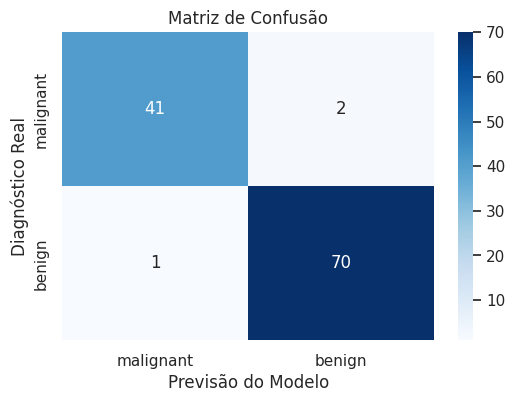

In [14]:
# Matriz de Confusão mostra exatamente onde o modelo acertou e onde errou
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)
plt.title('Matriz de Confusão')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Diagnóstico Real')
plt.show()

/tmp/ipykernel_28391/2021513412.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')


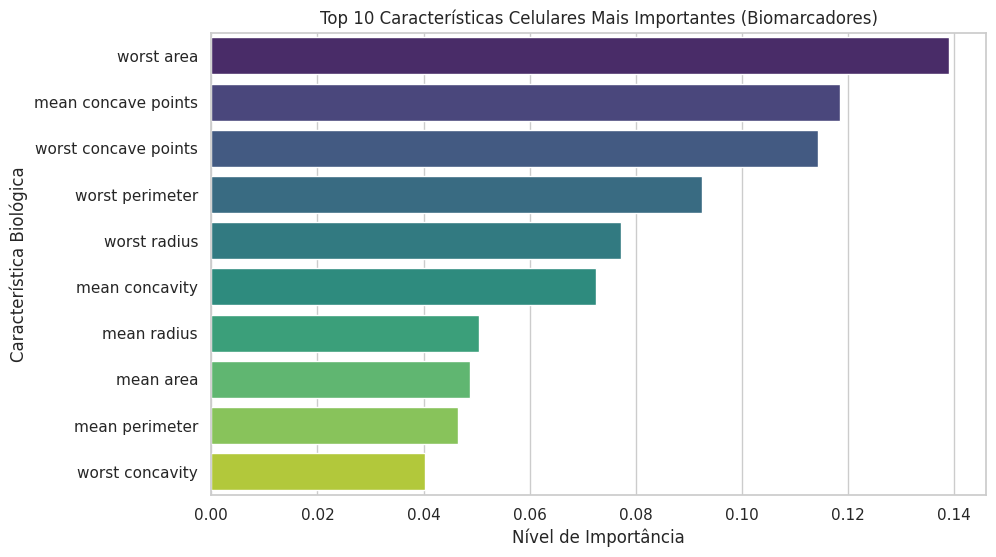

In [15]:
# uma das maiores vantagens do Random Forest em biologia é descobrir QUAIS fatores são mais importantes.
# aqui extraímos o nível de importância que o modelo deu para cada característica da célula.
importances = rf_model.feature_importances_

# criando um DataFrame para facilitar a visualização e ordenando do mais pro menos importante
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# plotando as 10 características biológicas mais determinantes para o modelo
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')
plt.title('Top 10 Características Celulares Mais Importantes (Biomarcadores)')
plt.xlabel('Nível de Importância')
plt.ylabel('Característica Biológica')
plt.show()